---
title: "Blog 04: Analysis of Pennsylvania Crash Data"
description: "placeholder"
author: "Daniel Park"
date: "2/25/2026"
categories:
  - car crashes
  - data stories
  - data visualization
---

Road crashes are a major public safety issue in large cities, where dense traffic, complex road networks, and pedestrian activity interact in unpredictable ways. Philadelphia has long struggled with dangerous road corridors, particularly wide arterial roads where high vehicle speeds mix with local traffic and pedestrian activity.

Some roads in the city have developed a particularly strong reputation for danger. Roosevelt Boulevard, for example, is frequently cited as one of the most dangerous roads in Philadelphia. According to an article by the Philadelphia Tribune, "between 2011 and 2015, about 13 percent of the city’s traffic fatalities occurred on the 16-mile stretch of Roosevelt Boulevard running from Hunting Park to just beyond the city line in Bensalem. During that period the corridor saw more than 60 deaths and roughly 4,700 injuries, with pedestrians accounting for about one-third of those killed on the 12-lane road." Other analyses of PennDOT crash data have also noted that Philadelphia contains a disproportionate share of Pennsylvania’s deadliest road segments. According to WarperNewman, corridors such as the Delaware Expressway (I-95), the Schuylkill Expressway (I-76), and sections of Broad Street frequently appear among the most dangerous in the state.

In this post, I analyze nearly two decades of Pennsylvania Department of Transportation (PennDOT) crash records to better understand patterns in Philadelphia traffic collisions. Using geospatial analysis and data visualisation, I first examine how crashes are distributed across the city and how crash severity changes over time and by time of day. I then take a closer look at several major corridors, including Roosevelt Boulevard, Broad Street, and the city’s two main expressways, I-95 and I-76, to investigate whether the patterns in the data support their reputation as some of the most dangerous roads in the region.

In response to persistent fatalities on Roosevelt Boulevard, the city has introduced automated speed enforcement cameras along sections of the corridor in an effort to reduce speeding and improve safety. Early reports suggest that these cameras have significantly reduced fatal crashes, raising an important question: how much can targeted policy interventions influence road safety outcomes?

Sources:

[Philly’s riskiest and deadliest roads are concentrated in Black and Brown neighborhoods](https://www.phillytrib.com/news/local_news/philly-s-riskiest-deadliest-roads-in-black-and-brown-neighborhoods/article_1d03b88e-2edf-5cbd-9f42-dd5eddf8fedf.html)

[5 of the Most Dangerous Roads in the U.S.](https://www.hg.org/legal-articles/5-of-the-most-dangerous-roads-in-the-u-s--32057)

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import camelot
import calendar
import re
import matplotlib.pyplot as plt

from shapely.geometry import Point

In [2]:
crash_data = pd.read_csv("data/PDOT_crash_data_2005_2024.csv", low_memory=False)
philly_zip = gpd.read_file("data/philadelphia_zip_boundaries.geojson")
data_dictionary = pd.read_csv('data/data_dictionary.csv')
div_gdf = gpd.read_file("data/Political_Divisions.geojson")
streets = gpd.read_file("data/Street_Centerline.geojson")

## Spatial distribution of crashes across Philadelphia

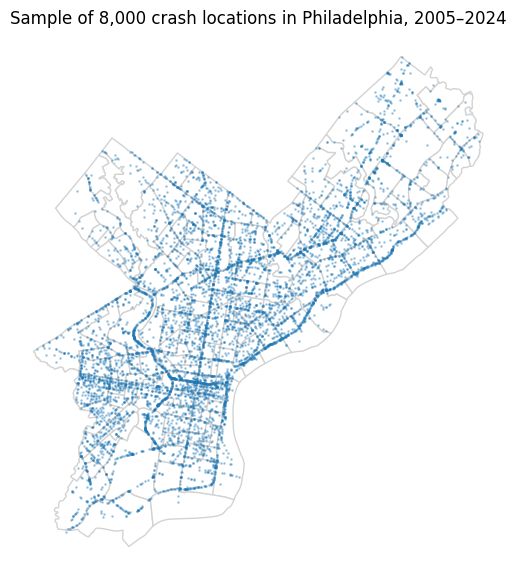

In [3]:
phil_filter = crash_data['COUNTY'] == 67

phil_crashes = crash_data[phil_filter].copy()

# remove rows without decimal coordinates
phil_crashes = phil_crashes.dropna(subset=['DEC_LATITUDE','DEC_LONGITUDE'])

phil_crashes.shape

geom = gpd.points_from_xy(phil_crashes['DEC_LONGITUDE'], phil_crashes['DEC_LATITUDE'])
phil_crashes_gdf = gpd.GeoDataFrame(phil_crashes, geometry=geom).set_crs('EPSG:4326')

philly_zip = gpd.read_file("data/philadelphia_zip_boundaries.geojson")

base = philly_zip.plot(color='white', edgecolor='lightgray', figsize=(7,7))
phil_crashes_gdf.sample(8000).plot(ax=base, markersize=1, alpha=0.3)
base.axis('off')
plt.title("Sample of 8,000 crash locations in Philadelphia, 2005–2024")
plt.show()

From the above spatial distribution of 8,000 sampled crashes across Philadelphia, we can see several clear patterns. Collisions are not evenly distributed across the city; instead, they cluster heavily along major transportation corridors and in the dense street grid of Center City and North Philadelphia. These areas contain high traffic volumes, frequent intersections, and significant pedestrian activity, all of which increase the likelihood of conflict between road users.

Several prominent linear patterns are also visible in the map, where crashes align along major arterial roads that cut across the city. We can see that the Schuylkill Expressway running along the river has a constant band of incidents, and we can see a strong band along Vine St Expressway which connects the I-76 to the Delaware Expressway, I-95. 

Passing straight through north from the middle of Center City, we can observe the band of incidents along Broad Street, then moving north east, we see Roosevelt Boulevard, which was one the most dangerous roads from 2011-2015, with a strong band of incidents heading north. 

These patterns highlight an important feature of urban road safety: risk is often concentrated along specific corridors rather than evenly spread across the network, as outlined in the articles. In the next section, we examine several of these corridors in more detail, beginning with Roosevelt Boulevard, which has long been regarded as one of the most dangerous roads in Philadelphia.

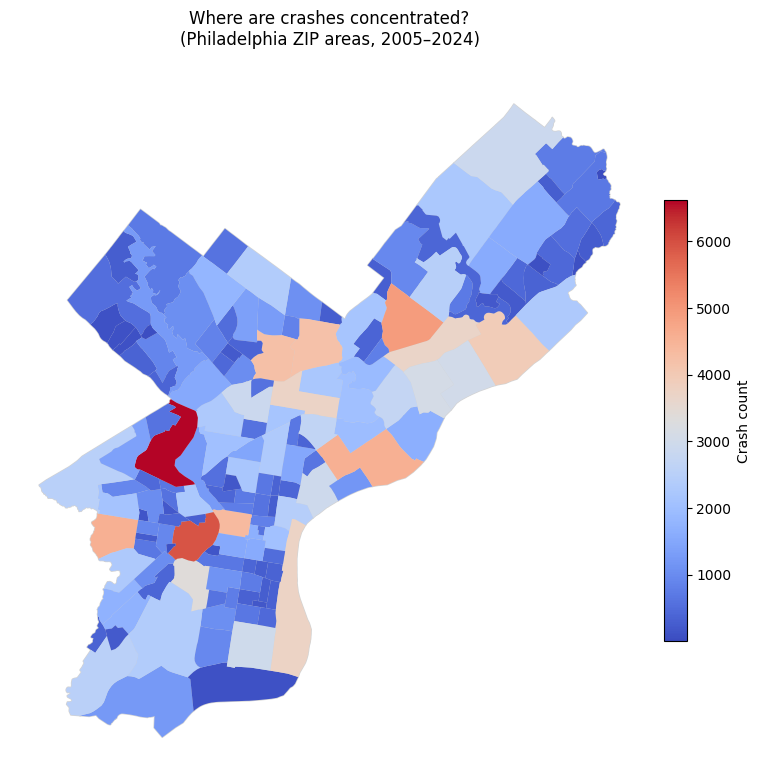

In [4]:
# spatial join: crashes -> zip polygons
zjoin = gpd.sjoin(philly_zip, phil_crashes_gdf, how='left', predicate='contains')

# dissolve by zip and count CRN values
zip_counts = zjoin.dissolve(by='listname', aggfunc={'CRN': 'count'})

# rename to a friendly column name
zip_counts = zip_counts.rename(columns={'CRN': 'crash_count'})

fig, ax = plt.subplots(figsize=(8,8))

philly_zip.plot(ax=ax, color='white', edgecolor='lightgray')

zip_counts.plot(
    ax=ax,
    column='crash_count',
    cmap='coolwarm',   # blue low -> red high
    legend=True,
    legend_kwds={'shrink': 0.6, 'label': 'Crash count', 'pad': 0.02}
)

ax.set_title("Where are crashes concentrated?\n(Philadelphia ZIP areas, 2005–2024)", pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

While the previous map shows the precise locations of individual crashes, it can be difficult to identify broader geographic patterns when thousands of points overlap across the city. Aggregating crashes by ZIP code helps reveal where incidents are most concentrated across Philadelphia.

Several ZIP codes in and around Center City record the highest total number of crashes. This is true because dense, urban neighbourhoods contain a tightly packed street grid, heavy traffic volumes, and many intersections where vehicles, cyclists, and pedestrians interact frequently. These conditions increase the number of potential conflict points, leading to more incidents overall.

However, a higher number of crashes does not necessarily imply more severe outcomes. In dense areas, traffic tends to move more slowly due to congestion, traffic lights, and frequent intersections. While minor collisions may occur more often in these environments, lower speeds typically reduce the likelihood of fatal outcomes.

In contrast, many of the most severe crashes occur on large arterial roads where vehicles travel at higher speeds and traffic flows more continuously. These wide corridors carry large volumes of vehicles and often combine fast-moving traffic with turning movements and pedestrian crossings. As a result, while dense neighbourhoods may experience more incidents overall, the most dangerous crashes frequently occur on major roadways such as Roosevelt Boulevard and other high-speed corridors across the city.

In [5]:
df = phil_crashes.copy()
df = df[df['HOUR_OF_DAY'].between(0, 23)]

df['night'] = df['HOUR_OF_DAY'].isin([20, 21, 22, 23, 0, 1, 2, 3, 4])

night_day = (
    df.groupby('night').agg(
          crashes=('CRN','count'),
          fatalities=('FATAL_COUNT','sum'),
          injuries=('TOT_INJ_COUNT','sum'),
          ped_deaths=('PED_DEATH_COUNT','sum'),
      )
)

night_day['fatalities_per_1000_crashes'] = 1000 * night_day['fatalities'] / night_day['crashes']
night_day['injuries_per_100_crashes']    = 100  * night_day['injuries'] / night_day['crashes']
night_day['ped_deaths_per_1000_crashes'] = 1000 * night_day['ped_deaths'] / night_day['crashes']

night_day.index = night_day.index.map({False: 'Day', True: 'Night'})

night_day

,crashes,fatalities,injuries,ped_deaths,fatalities_per_1000_crashes,injuries_per_100_crashes,ped_deaths_per_1000_crashes
night,,,,,,,
Day,5948,41,6275,15,6.893073,105.497646,2.521856
Night,2467,54,2329,18,21.888934,94.406161,7.296311


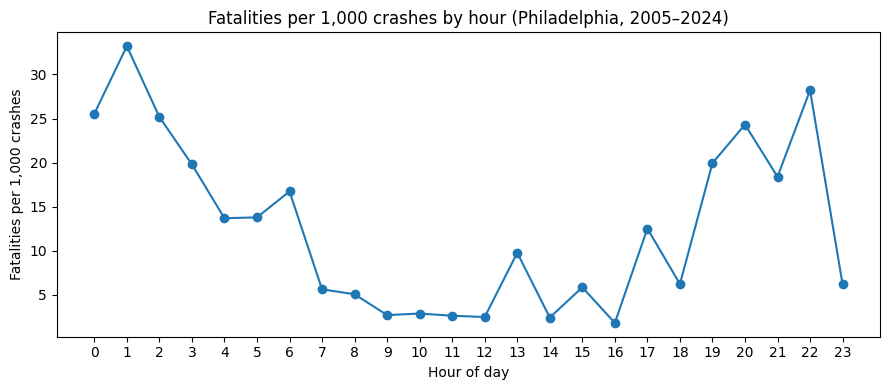

In [6]:
hour = (
    df.groupby('HOUR_OF_DAY')
      .agg(crashes=('CRN','count'),
           fatalities=('FATAL_COUNT','sum'),
           injuries=('TOT_INJ_COUNT','sum'))
)

hour['fatalities_per_1000_crashes'] = 1000 * hour['fatalities'] / hour['crashes']

plt.figure(figsize=(9,4))
plt.plot(hour.index, hour['fatalities_per_1000_crashes'], marker='o')
plt.title("Fatalities per 1,000 crashes by hour (Philadelphia, 2005–2024)")
plt.xlabel("Hour of day")
plt.ylabel("Fatalities per 1,000 crashes")
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

## Roosevelt Boulevard: Philadelphia’s most dangerous road

In [7]:
# ---------------------------------------------
# Roosevelt Boulevard crash analysis (corridor buffer method)
# ---------------------------------------------

# 1) find Roosevelt Blvd segments (main boulevard + optional ramps)
rb_main = streets[
    (streets["st_name"].str.upper().eq("ROOSEVELT")) &
    (streets["st_type"].str.upper().eq("BLVD"))
].copy()

rb_ramps = streets[
    (streets["st_name"].str.upper().str.contains("ROOSEVELT", na=False)) &
    (streets["st_type"].str.upper().eq("RAMP"))
].copy()

roosevelt = pd.concat([rb_main, rb_ramps], ignore_index=True)

# 2) project to feet CRS for buffering
roosevelt = roosevelt.to_crs(epsg=2272)

# 3) create corridor buffer around Roosevelt Blvd
buffer_ft = 100
roosevelt_buf = gpd.GeoDataFrame(
    geometry=roosevelt.buffer(buffer_ft),
    crs=roosevelt.crs
)

# 4) restrict crashes to analysis period
city_11_15 = phil_crashes_gdf[
    (phil_crashes_gdf["CRASH_YEAR"] >= 2011) &
    (phil_crashes_gdf["CRASH_YEAR"] <= 2015)
].copy()

city_11_15 = city_11_15.to_crs(epsg=2272)

city_fatalities = city_11_15["FATAL_COUNT"].sum()

# 5) spatial join crashes within Roosevelt Blvd corridor
joined = gpd.sjoin(city_11_15, roosevelt_buf, predicate="within")
joined = joined.drop_duplicates(subset=["CRN"])  # avoid double-counting

# 6) compute statistics
rb_fatalities = joined["FATAL_COUNT"].sum()
rb_share = rb_fatalities / city_fatalities if city_fatalities else float("nan")

rb_injuries = joined["TOT_INJ_COUNT"].sum()
rb_ped_deaths = joined["PED_DEATH_COUNT"].sum()
rb_ped_share = rb_ped_deaths / rb_fatalities if rb_fatalities > 0 else float("nan")

print("\n--- Roosevelt Boulevard ---")
print("Crashes matched:", len(joined))
print("Fatalities:", int(rb_fatalities))
print("Share of city fatalities:", round(rb_share, 4), f"({rb_share:.1%})")
print("Injuries:", int(rb_injuries))
print("Pedestrian deaths:", int(rb_ped_deaths))
print("Pedestrian share of deaths:", round(rb_ped_share, 4), f"({rb_ped_share:.1%})")


--- Roosevelt Boulevard ---
Crashes matched: 3606
Fatalities: 65
Share of city fatalities: 0.1377 (13.8%)
Injuries: 4445
Pedestrian deaths: 22
Pedestrian share of deaths: 0.3385 (33.8%)


In [8]:
# Helper function to compute crash statistics using a buffer.

def corridor_stats(crash_gdf, corridor_buf):
    joined = gpd.sjoin(crash_gdf, corridor_buf, predicate='within')
    joined = joined.drop_duplicates(subset=['CRN'])

    total_fatal = crash_gdf['FATAL_COUNT'].sum()
    corridor_fatal = joined['FATAL_COUNT'].sum()

    share = corridor_fatal / total_fatal if total_fatal > 0 else np.nan

    return corridor_fatal, total_fatal, share


# ------------------------------------------------------------
# Roosevelt Blvd share of city fatalities over time
# ------------------------------------------------------------

all_crashes = phil_crashes_gdf.to_crs(epsg=2272)

years = sorted(all_crashes['CRASH_YEAR'].unique())
year_results = []

for y in years:
    subset = all_crashes[all_crashes['CRASH_YEAR'] == y]
    rb_fatal, city_fatal, share = corridor_stats(subset, rb_buf)
    year_results.append([y, rb_fatal, city_fatal, share])

year_df = pd.DataFrame(year_results, columns=['year','rb_fatal','city_fatal','share'])

plt.figure(figsize=(8,4))
plt.plot(year_df['year'], year_df['share'], marker='o')
plt.axvline(2020, linestyle='--', color='red', alpha=0.6)
plt.title("Roosevelt Blvd Share of City Fatalities Over Time")
plt.ylabel("Share of City Fatalities")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

NameError: name 'rb_buf' is not defined

The figure shows the share of all Philadelphia traffic fatalities that occurred on Roosevelt Boulevard each year. For much of the period before 2020, the boulevard consistently accounted for a substantial proportion of the city’s traffic deaths. In several years it represented more than 15 percent of all fatalities, and in some years exceeded 20 percent, reinforcing its reputation as one of the most dangerous roads in Philadelphia.

The dashed vertical line marks June 2020, when automated speed enforcement cameras were introduced along several segments of Roosevelt Boulevard as part of Philadelphia’s Vision Zero campaign. The program was implemented after years of concern about the continual incidents and fatailies along the road. At the time, the boulevard was widely regarded as the most dangerous road in the city and among the most dangerous in Pennsylvania.

Following the introduction of automated speed enforcement, the boulevard’s share of citywide fatalities appears to decline significantly. While yearly values continued to fluctuate, the proportion of fatalities occurring on Roosevelt Boulevard remains noticeably lower in the years after 2020 compared with many earlier years in the dataset.

Reports from the Philadelphia Parking Authority support this pattern. According to the agency, speeding tickets on Roosevelt Boulevard have fallen by 93 percent since the cameras were installed, while fatal and serious injury crashes have decreased by 21 percent and pedestrian-involved crashes have dropped by 50 percent. The apparent reduction in the boulevard’s share of city fatalities after 2020 is therefore consistent with the improvements reported following the introduction of automated speed enforcement.

The perceived success of the program led Pennsylvania legislators to make the camera pilot permanent and allow the city to expand automated speed enforcement to additional corridors. In 2023, the program was extended to several new roads, including sections of Route 611, which covers much of Broad Street, which we will explore next.

In [ ]:
# ------------------------------------------------------------
# Broad Street corridor creation
# ------------------------------------------------------------

broad = streets[
    (streets['st_name'].str.upper() == 'BROAD') &
    (streets['st_type'].str.upper() == 'ST')
].copy()

broad = broad.to_crs(epsg=2272)

buffer_ft = 100
broad_buf = gpd.GeoDataFrame(geometry=broad.buffer(buffer_ft), crs=broad.crs)


# ------------------------------------------------------------
# Broad Street crash statistics (2011–2015)
# ------------------------------------------------------------

city_11_15 = phil_crashes_gdf.query("2011 <= CRASH_YEAR <= 2015").to_crs(epsg=2272)

joined = gpd.sjoin(city_11_15, broad_buf, predicate='within').drop_duplicates('CRN')

city_fatalities = city_11_15['FATAL_COUNT'].sum()
broad_fatalities = joined['FATAL_COUNT'].sum()

broad_share = broad_fatalities / city_fatalities if city_fatalities else np.nan

broad_injuries = joined['TOT_INJ_COUNT'].sum()
broad_ped_deaths = joined['PED_DEATH_COUNT'].sum()
broad_ped_share = broad_ped_deaths / broad_fatalities if broad_fatalities else np.nan

print("\n--- Broad Street ---")
print("Crashes matched:", len(joined))
print("Fatalities:", int(broad_fatalities))
print("Share of city fatalities:", f"{broad_share:.1%}")
print("Injuries:", int(broad_injuries))
print("Pedestrian deaths:", int(broad_ped_deaths))
print("Pedestrian share of deaths:", f"{broad_ped_share:.1%}")

In [ ]:
# ------------------------------------------------------------
# Broad Street share of city fatalities over time
# ------------------------------------------------------------

broad_year_results = []

for y in years:
    subset = all_crashes[all_crashes['CRASH_YEAR'] == y]
    b_fatal, city_fatal, share = corridor_stats(subset, broad_buf)
    broad_year_results.append([y, b_fatal, city_fatal, share])

broad_year_df = pd.DataFrame(broad_year_results, columns=['year','broad_fatal','city_fatal','share'])

plt.figure(figsize=(8,4))

plt.plot(broad_year_df['year'],
         broad_year_df['share'],
         marker='o',
         color='darkgreen',
         label='Broad Street share of city fatalities')

# vertical line for enforcement policy
plt.axvline(2025, linestyle='--', color='blue', alpha=0.7)

# annotation explaining the policy
plt.text(2025.1,
         broad_year_df['share'].max()*0.9,
         "Speed cameras installed\nSept 15, 2025\nFines begin Nov 14, 2025",
         fontsize=9,
         color='blue')

plt.title("Broad Street Share of City Fatalities Over Time")
plt.ylabel("Share of City Fatalities")
plt.xlabel("Year")

plt.tight_layout()
plt.show()

In [ ]:
https://6abc.com/post/broad-street-speed-cameras-activated-philadelphia-drivers-face-100-ticket/18154437/

In [ ]:
# ------------------------------------------------------------
# Fatalities per mile comparison
# ------------------------------------------------------------

rb_length = rb.length.sum() / 5280
broad_length = broad.length.sum() / 5280

rb_rate = rb_fatal / rb_length
broad_rate = broad_fatalities / broad_length

print("\nFatalities per mile")
print("Roosevelt Blvd:", round(rb_rate,2))
print("Broad Street:", round(broad_rate,2))

In [ ]:
# ------------------------------------------------------------
# Top 5 most dangerous roads by TOTAL fatalities (2011–2015)
# + sanity checks for Broad Street
# Assumes you already have: phil_crashes_gdf (points, EPSG:4326) and streets (lines)
# ------------------------------------------------------------

# 1) Filter crashes to the period + project to a feet CRS (good for length/distance)
crashes_11_15 = phil_crashes_gdf.query("2011 <= CRASH_YEAR <= 2015").copy()
crashes_11_15 = crashes_11_15.to_crs(epsg=2272)

# (Optional) drop weird rows with missing CRN just in case
crashes_11_15 = crashes_11_15.dropna(subset=["CRN"])

# 2) Prep streets: project + build a stable road identifier
streets_2272 = streets.to_crs(epsg=2272).copy()

# keep only rows that actually have a street name
streets_2272 = streets_2272.dropna(subset=["st_name"])

# Road label choices:
# - road_name: just the base name (BROAD, ROOSEVELT, etc.)
# - road_id: name + type (BROAD ST, ROOSEVELT BLVD) helps disambiguate
streets_2272["road_name"] = streets_2272["st_name"].str.upper().str.strip()
streets_2272["road_type"] = streets_2272["st_type"].fillna("").str.upper().str.strip()
streets_2272["road_id"]   = (streets_2272["road_name"] + " " + streets_2272["road_type"]).str.strip()

# 3) Build a buffered "corridor" around each street segment to catch nearby crash points
#    (This is WHY buffer exists: crash points aren't perfectly snapped to centerlines.)
buffer_ft = 100
roads_lines = streets_2272[["road_id", "road_name", "geometry"]].copy()
roads_corr  = roads_lines.copy()
roads_corr["geometry"] = roads_corr.buffer(buffer_ft)

# 4) Spatial join: crashes within any road corridor
#    At intersections, one crash may match multiple corridors → we resolve by nearest road segment.
j = gpd.sjoin(
    crashes_11_15[["CRN", "FATAL_COUNT", "TOT_INJ_COUNT", "PED_DEATH_COUNT", "geometry"]],
    roads_corr[["road_id", "road_name", "geometry"]],
    how="inner",
    predicate="within"
)

# 5) Attach the original LINE geometry (so we can compute distance to the road line)
#    After sjoin, the corridor geometry is in j.geometry and the road_id is present;
#    we merge the true line geometry in as "road_line".
j = j.merge(
    roads_lines[["road_id", "geometry"]].rename(columns={"geometry": "road_line"}),
    on="road_id",
    how="left"
)

# 6) Keep only the closest road match per CRN (prevents double counting)
road_line_gs = gpd.GeoSeries(j["road_line"], index=j.index, crs=crashes_11_15.crs)
j["dist_ft"] = j.geometry.distance(road_line_gs)

j_best = (
    j.sort_values("dist_ft")
     .drop_duplicates(subset=["CRN"])
     .copy()
)

# 7) Aggregate total fatalities per road (this is what you said you want)
fatal_by_road = (
    j_best.groupby("road_id")["FATAL_COUNT"]
          .sum()
          .sort_values(ascending=False)
)

top5_fatal = fatal_by_road.head(5)
print("\nTop 5 roads by TOTAL fatalities (2011–2015):")
print(top5_fatal)

## Comparing other major corridors

Roosevelt Boulevard and Broad Street are not the only roads frequently cited in discussions of traffic fatalities in Philadelphia. Legal analyses and safety reports have also identified the Delaware Expressway (I-95) and the Schuylkill Expressway (I-76) as among the most dangerous roads in Pennsylvania. Unlike the wide urban boulevards discussed earlier, these highways carry extremely high traffic volumes through the city.

While expressways typically have fewer intersections and pedestrian conflicts, their higher speeds can still produce severe crashes when collisions occur. To provide context, I compared crash outcomes on these two highways with those observed on Roosevelt Boulevard and Broad Street.

The results highlight an important distinction between road types. Although the expressways carry far more vehicles, many of the most severe crashes within the city still occur on large urban arterial roads where high speeds interact with turning traffic, intersections, and pedestrian crossings.

In [ ]:
# ------------------------------------------------------------
# Compare fatalities and pedestrian deaths across major roads
# ------------------------------------------------------------

roads = [
    "ROOSEVELT BLVD",
    "BROAD ST",
    "DELAWARE EXPY",
    "SCHUYLKILL EXPY"
]

# keep crashes on these corridors
corr = crashes_with_roads[
    crashes_with_roads["road_name"].isin(roads)
].copy()

# restrict to the same analysis period used earlier
corr = corr[
    (corr["CRASH_YEAR"] >= 2011) &
    (corr["CRASH_YEAR"] <= 2015)
]

# summarise fatalities and pedestrian deaths
summary = (
    corr.groupby("road_name")
    .agg(
        fatalities=("FATAL_COUNT","sum"),
        ped_deaths=("PED_DEATH_COUNT","sum"),
        crashes=("CRN","count")
    )
)

# compute pedestrian share of fatalities
summary["ped_share"] = summary["ped_deaths"] / summary["fatalities"]

print(summary.sort_values("fatalities", ascending=False))

In [ ]:
def period(year):
    if year <= 2012:
        return "2005-2012"
    elif year <= 2019:
        return "2013-2019"
    else:
        return "2020-2024"

phil_crashes_gdf['period'] = phil_crashes_gdf['CRASH_YEAR'].apply(period)

period_counts = phil_crashes_gdf.groupby('period').size()
period_counts.plot(kind='bar')